# Análise de Resultados por Cenário - Simulação OAI 5G

Análise integrada dos resultados de 3 cenários de simulação 5G OAI:
- **Cenário 1**: Tráfego benign apenas
- **Cenário 2 & 3**: Tráfego benign + ataques diversos

Este notebook carrega, visualiza e compara os resultados de cada cenário.

## 1. Importar Bibliotecas Necessárias

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Configurar estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## 2. Carregar Dados dos Resultados

In [17]:
# Definir caminho base
results_path = Path('/Users/drt82247/Documents/Projetos/IME/CDR/oai/oai-workshops/cn/results')

# Carregar dados de cada cenário
scenarios = {}
for i in range(1, 4):
    scenario_path = results_path / f'scenario {i}'
    csv_file = scenario_path / f'cve5g_s{i}_labels.csv'
    
    if csv_file.exists():
        df = pd.read_csv(csv_file)
        scenarios[f'Cenário {i}'] = {
            'data': df,
            'path': scenario_path
        }
        print(f"✅ Cenário {i} carregado: {len(df)} registros")
    else:
        print(f"❌ Arquivo não encontrado: {csv_file}")

print(f"\n📊 Total de cenários carregados: {len(scenarios)}")


✅ Cenário 1 carregado: 2 registros
✅ Cenário 2 carregado: 8 registros
✅ Cenário 3 carregado: 8 registros

📊 Total de cenários carregados: 3


In [18]:
# Visualizar estrutura dos dados
for scenario_name, scenario_info in scenarios.items():
    print(f"\n{'='*60}")
    print(f"{scenario_name}")
    print(f"{'='*60}")
    print(scenario_info['data'])
    print(f"\nTipos de tráfego único:")
    print(scenario_info['data']['label'].unique())



Cenário 1
                label    src_ip               dst_ip  t_start  t_end
0      benign_iso_tcp  10.0.0.2  releases.ubuntu.com       30    300
1  benign_ytdlp_https  10.0.0.2          youtube.com       30    300

Tipos de tráfego único:
<StringArray>
['benign_iso_tcp', 'benign_ytdlp_https']
Length: 2, dtype: str

Cenário 2
                       label          src_ip               dst_ip  t_start  \
0             benign_iso_tcp        10.0.0.2  releases.ubuntu.com       30   
1         benign_ytdlp_https        10.0.0.2          youtube.com       30   
2            attack_portscan  192.168.70.140       192.168.70.132       40   
3           attack_syn_flood  192.168.70.140       192.168.70.132       85   
4           attack_udp_flood  192.168.70.140       192.168.70.132      130   
5          attack_icmp_flood  192.168.70.140       192.168.70.132      178   
6           attack_cve_65805  192.168.70.140       192.168.70.132      230   
7  benign_interrupted_by_cve  192.168.70.132 

## 3. Análise de Logs de Crash (Cenários 2 e 3)

In [19]:
# Verificar logs de crash
crash_logs = {}
for i in [2, 3]:
    scenario_path = results_path / f'scenario {i}'
    log_file = scenario_path / f'amf_crash_s{i}.log'
    
    if log_file.exists():
        with open(log_file, 'r') as f:
            content = f.read()
            crash_logs[f'Cenário {i}'] = {
                'file_path': log_file,
                'file_size': log_file.stat().st_size,
                'has_content': len(content) > 0,
                'first_lines': content[:500] if content else "Arquivo vazio"
            }
            print(f"✅ Log de crash Cenário {i}: {log_file.stat().st_size} bytes")
    else:
        print(f"❌ Log não encontrado: {log_file}")

# Exibir resumo dos logs
for scenario_name, log_info in crash_logs.items():
    print(f"\n{scenario_name} - Tamanho: {log_info['file_size']} bytes")
    print("Primeiras linhas:")
    print(log_info['first_lines'][:300])


✅ Log de crash Cenário 2: 4561 bytes
✅ Log de crash Cenário 3: 4694 bytes

Cenário 2 - Tamanho: 4561 bytes
Primeiras linhas:
   |---------------------------------------------------------------------UEs' Information----------------------------------------------------------------------|
   |  Index |     5GMM State     |        IMSI        |        GUTI        |   RAN UE NGAP ID   |   AMF UE NGAP ID   |        PLMN        |

Cenário 3 - Tamanho: 4694 bytes
Primeiras linhas:
[2026-05-22 04:11:25.684] [amf_sbi] [info] Get response with HTTP code (204)
[2026-05-22 04:11:25.684] [amf_sbi] [info] Could not get JSON content from the response
[2026-05-22 04:11:25.684] [amf_sbi] [debug] NF Update, response from NRF, JSON data: 
 null
[2026-05-22 04:11:25.684] [amf_app] [debug]


## 4. Análise Detalhada por Cenário

In [20]:
# Classificar tráfego em benign vs attack
analysis_results = {}

for scenario_name, scenario_info in scenarios.items():
    df = scenario_info['data'].copy()
    
    # Classificar
    df['traffic_type'] = df['label'].apply(
        lambda x: 'Benign' if 'benign' in x.lower() else 'Attack'
    )
    
    # Extrair tipo de ataque/tráfego
    df['traffic_category'] = df['label'].apply(
        lambda x: x.split('_', 1)[1] if '_' in x else x
    )
    
    # Calcular duração
    df['duration'] = df['t_end'] - df['t_start']
    
    # Análise
    benign_count = (df['traffic_type'] == 'Benign').sum()
    attack_count = (df['traffic_type'] == 'Attack').sum()
    total_time = df['t_end'].max()
    
    analysis_results[scenario_name] = {
        'df': df,
        'benign_count': benign_count,
        'attack_count': attack_count,
        'total_time': total_time,
        'benign_ratio': benign_count / len(df) * 100
    }
    
    print(f"\n{'='*50}")
    print(f"{scenario_name}")
    print(f"{'='*50}")
    print(f"Total de fluxos: {len(df)}")
    print(f"Tráfego Benign: {benign_count} ({analysis_results[scenario_name]['benign_ratio']:.1f}%)")
    print(f"Tráfego Malicioso: {attack_count} ({100-analysis_results[scenario_name]['benign_ratio']:.1f}%)")
    print(f"Duração total: {total_time}s")
    print(f"\nDistribuição de categorias:")
    print(df['traffic_category'].value_counts())



Cenário 1
Total de fluxos: 2
Tráfego Benign: 2 (100.0%)
Tráfego Malicioso: 0 (0.0%)
Duração total: 300s

Distribuição de categorias:
traffic_category
iso_tcp        1
ytdlp_https    1
Name: count, dtype: int64

Cenário 2
Total de fluxos: 8
Tráfego Benign: 3 (37.5%)
Tráfego Malicioso: 5 (62.5%)
Duração total: 300s

Distribuição de categorias:
traffic_category
iso_tcp               1
ytdlp_https           1
portscan              1
syn_flood             1
udp_flood             1
icmp_flood            1
cve_65805             1
interrupted_by_cve    1
Name: count, dtype: int64

Cenário 3
Total de fluxos: 8
Tráfego Benign: 3 (37.5%)
Tráfego Malicioso: 5 (62.5%)
Duração total: 300s

Distribuição de categorias:
traffic_category
iso_tcp               1
ytdlp_https           1
portscan              1
syn_flood             1
udp_flood             1
icmp_flood            1
cve_65805             1
interrupted_by_cve    1
Name: count, dtype: int64


## 5. Visualizações Comparativas

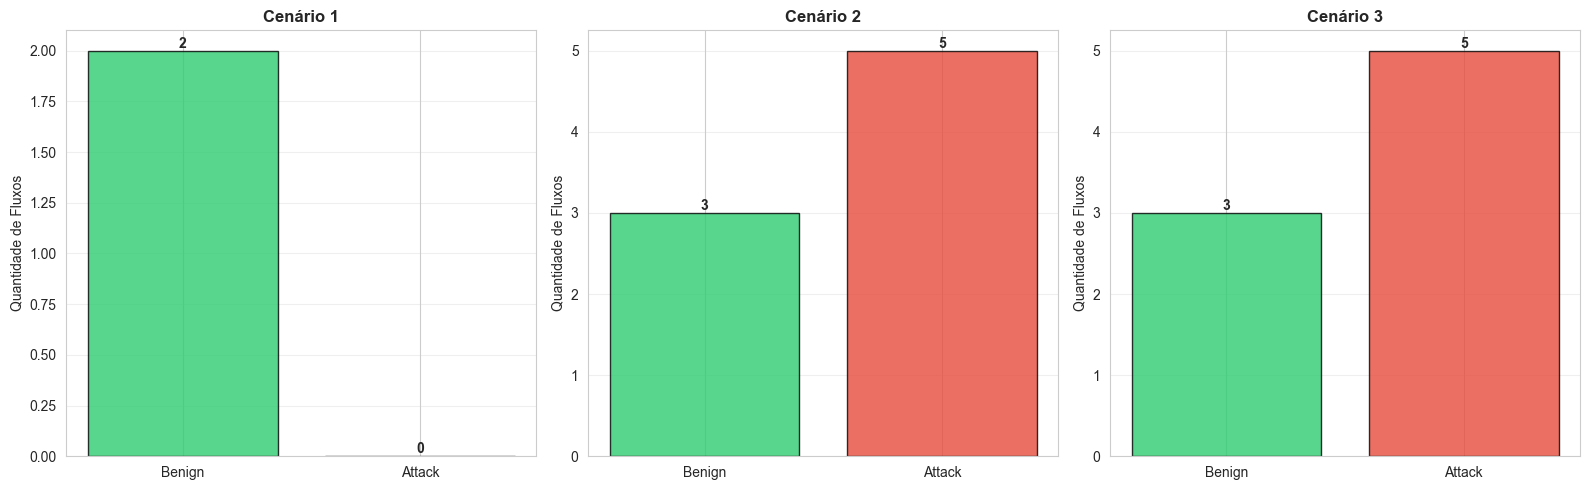

✅ Gráfico de comparação Benign vs Attack salvo


In [21]:
### 5.1. Comparação: Tráfego Benign vs Attack por Cenário

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (scenario_name, result) in enumerate(analysis_results.items()):
    counts = [result['benign_count'], result['attack_count']]
    colors = ['#2ecc71', '#e74c3c']
    
    axes[idx].bar(['Benign', 'Attack'], counts, color=colors, alpha=0.8, edgecolor='black')
    axes[idx].set_title(f'{scenario_name}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Quantidade de Fluxos', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Adicionar valores nas barras
    for i, (label, count) in enumerate(zip(['Benign', 'Attack'], counts)):
        axes[idx].text(i, count, str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(results_path / 'comparacao_benign_vs_attack.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico de comparação Benign vs Attack salvo")


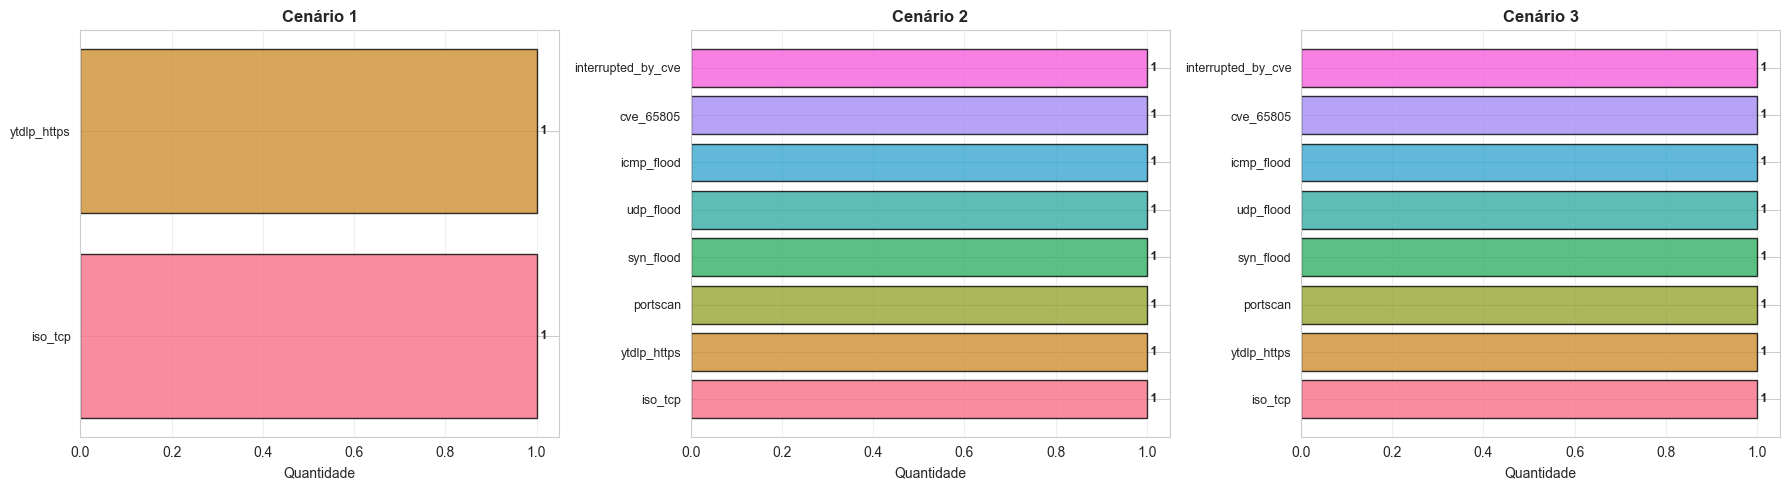

✅ Gráfico de distribuição de tipos de tráfego salvo


In [22]:
### 5.2. Distribuição de Tipos de Tráfego por Cenário

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_palette = sns.color_palette("husl", 8)

for idx, (scenario_name, result) in enumerate(analysis_results.items()):
    df = result['df']
    traffic_counts = df['traffic_category'].value_counts()
    
    axes[idx].barh(range(len(traffic_counts)), traffic_counts.values, 
                   color=colors_palette[:len(traffic_counts)], edgecolor='black', alpha=0.8)
    axes[idx].set_yticks(range(len(traffic_counts)))
    axes[idx].set_yticklabels(traffic_counts.index, fontsize=9)
    axes[idx].set_xlabel('Quantidade', fontsize=10)
    axes[idx].set_title(f'{scenario_name}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)
    
    # Adicionar valores nas barras
    for i, v in enumerate(traffic_counts.values):
        axes[idx].text(v, i, f' {v}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(results_path / 'distribuicao_tipos_trafego.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico de distribuição de tipos de tráfego salvo")


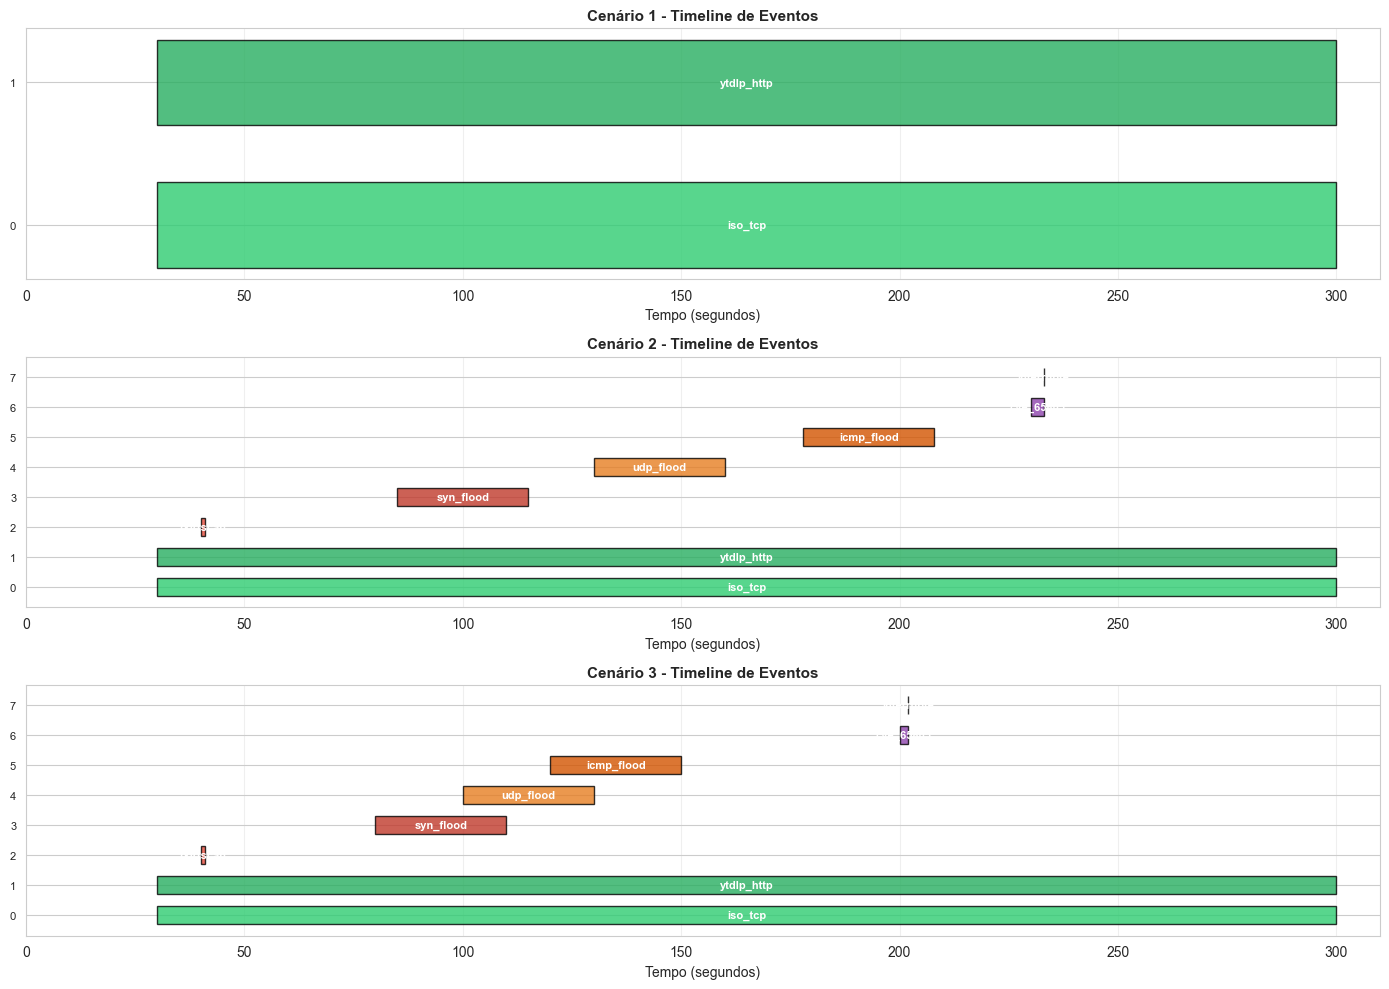

✅ Gráfico de timeline salvo


In [23]:
### 5.3. Timeline de Eventos por Cenário

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

attack_colors = {
    'portscan': '#e74c3c',
    'syn_flood': '#c0392b',
    'udp_flood': '#e67e22',
    'icmp_flood': '#d35400',
    'cve_65805': '#8e44ad',
    'iso_tcp': '#2ecc71',
    'ytdlp_https': '#27ae60',
    'interrupted_by_cve': '#95a5a6'
}

for idx, (scenario_name, result) in enumerate(analysis_results.items()):
    df = result['df']
    
    # Plotar cada evento como uma linha na timeline
    for row_idx, (_, row) in enumerate(df.iterrows()):
        color = attack_colors.get(row['traffic_category'], '#3498db')
        axes[idx].barh(row_idx, row['duration'], left=row['t_start'], 
                      height=0.6, color=color, edgecolor='black', alpha=0.8)
        axes[idx].text(row['t_start'] + row['duration']/2, row_idx, 
                      row['traffic_category'][:10], 
                      ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    
    axes[idx].set_yticks(range(len(df)))
    axes[idx].set_yticklabels(df.index, fontsize=8)
    axes[idx].set_xlabel('Tempo (segundos)', fontsize=10)
    axes[idx].set_title(f'{scenario_name} - Timeline de Eventos', fontsize=11, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)
    axes[idx].set_xlim(0, df['t_end'].max() + 10)

plt.tight_layout()
plt.savefig(results_path / 'timeline_eventos.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico de timeline salvo")


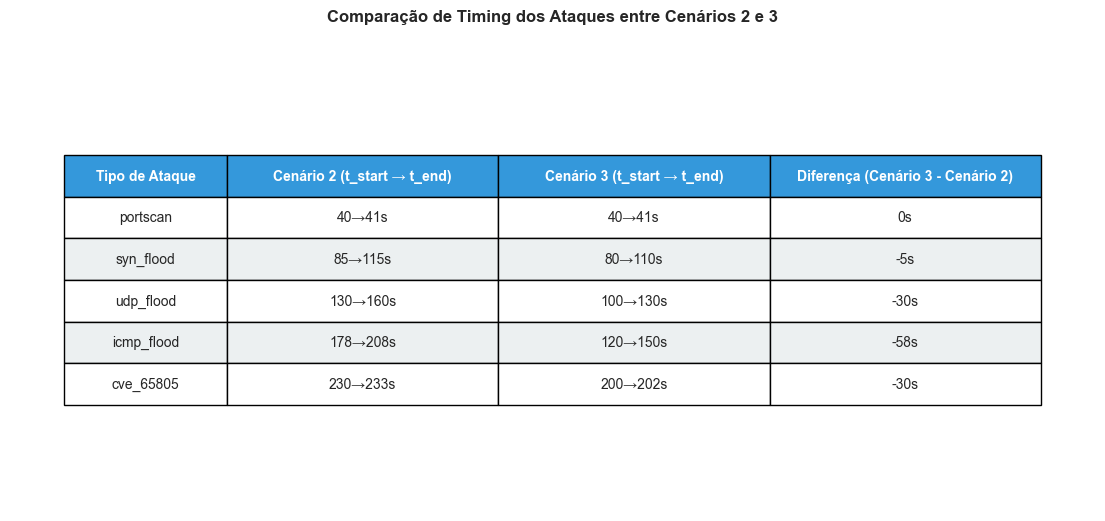

✅ Tabela de comparação de timing salva


In [24]:
### 5.4. Comparação de Timing dos Ataques (Cenários 2 e 3)

# Extrair ataques apenas
attacks = {}
for scenario_name in ['Cenário 2', 'Cenário 3']:
    if scenario_name in analysis_results:
        attacks[scenario_name] = analysis_results[scenario_name]['df'][
            analysis_results[scenario_name]['df']['traffic_type'] == 'Attack'
        ].copy()

# Criar tabela comparativa
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('tight')
ax.axis('off')

comparison_data = []
headers = ['Tipo de Ataque', 'Cenário 2 (t_start → t_end)', 'Cenário 3 (t_start → t_end)', 'Diferença (Cenário 3 - Cenário 2)']

attack_types = ['portscan', 'syn_flood', 'udp_flood', 'icmp_flood', 'cve_65805']

for attack_type in attack_types:
    s2_row = attacks['Cenário 2'][attacks['Cenário 2']['traffic_category'] == attack_type]
    s3_row = attacks['Cenário 3'][attacks['Cenário 3']['traffic_category'] == attack_type]
    
    if len(s2_row) > 0 and len(s3_row) > 0:
        s2_time = f"{s2_row['t_start'].values[0]:.0f}→{s2_row['t_end'].values[0]:.0f}s"
        s3_time = f"{s3_row['t_start'].values[0]:.0f}→{s3_row['t_end'].values[0]:.0f}s"
        diff = s3_row['t_start'].values[0] - s2_row['t_start'].values[0]
        diff_str = f"+{diff:.0f}s" if diff > 0 else f"{diff:.0f}s"
        
        comparison_data.append([attack_type, s2_time, s3_time, diff_str])

table = ax.table(cellText=comparison_data, colLabels=headers, cellLoc='center', loc='center',
                colWidths=[0.15, 0.25, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Colorir header
for i in range(len(headers)):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Colorir linhas alternadas
for i in range(1, len(comparison_data) + 1):
    for j in range(len(headers)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#ffffff')

plt.title('Comparação de Timing dos Ataques entre Cenários 2 e 3', 
         fontsize=12, fontweight='bold', pad=20)
plt.savefig(results_path / 'comparacao_timing_ataques.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Tabela de comparação de timing salva")


## 6. Comparação com Resultados Esperados

In [25]:
# Definir resultados esperados baseados na configuração da simulação
expected_results = {
    'Cenário 1': {
        'description': 'Teste de baseline - Apenas tráfego benign',
        'expected_benign': 2,
        'expected_attacks': 0,
        'expected_types': ['iso_tcp', 'ytdlp_https'],
        'expected_issues': 'Nenhum. Sistema operacional normalmente.'
    },
    'Cenário 2': {
        'description': 'Testes de robustez - Múltiplos ataques sequenciais',
        'expected_benign': 2,
        'expected_attacks': 5,
        'expected_types': ['iso_tcp', 'ytdlp_https', 'portscan', 'syn_flood', 'udp_flood', 'icmp_flood', 'cve_65805'],
        'expected_issues': 'Possível crash/indisponibilidade do AMF durante/após CVE-65805'
    },
    'Cenário 3': {
        'description': 'Teste de replicação com timing ajustado',
        'expected_benign': 2,
        'expected_attacks': 5,
        'expected_types': ['iso_tcp', 'ytdlp_https', 'portscan', 'syn_flood', 'udp_flood', 'icmp_flood', 'cve_65805'],
        'expected_issues': 'Mesmo comportamento que Cenário 2, com timing levemente diferente'
    }
}

# Comparar com observado
print("="*80)
print("VALIDAÇÃO CONTRA RESULTADOS ESPERADOS")
print("="*80)

validation_results = {}

for scenario_name, expected in expected_results.items():
    if scenario_name in analysis_results:
        observed = analysis_results[scenario_name]
        df = observed['df']
        
        print(f"\n{scenario_name}")
        print("-" * 80)
        print(f"Descrição: {expected['description']}")
        
        # Validar contagens
        benign_match = observed['benign_count'] == expected['expected_benign']
        attack_match = observed['attack_count'] == expected['expected_attacks']
        
        print(f"\n✓ Tráfego Benign:")
        print(f"  Esperado: {expected['expected_benign']} | Observado: {observed['benign_count']} | Resultado: {'✅ OK' if benign_match else '❌ DIVERGÊNCIA'}")
        
        print(f"\n✓ Tráfego Malicioso:")
        print(f"  Esperado: {expected['expected_attacks']} | Observado: {observed['attack_count']} | Resultado: {'✅ OK' if attack_match else '❌ DIVERGÊNCIA'}")
        
        # Validar tipos
        observed_types = set(df['traffic_category'].unique())
        expected_types_set = set(expected['expected_types'])
        types_match = observed_types == expected_types_set
        
        print(f"\n✓ Tipos de Tráfego:")
        print(f"  Esperado: {sorted(expected_types_set)}")
        print(f"  Observado: {sorted(observed_types)}")
        print(f"  Resultado: {'✅ OK' if types_match else '❌ DIVERGÊNCIA'}")
        
        if not types_match:
            missing = expected_types_set - observed_types
            extra = observed_types - expected_types_set
            if missing:
                print(f"  - Faltando: {missing}")
            if extra:
                print(f"  - Extra: {extra}")
        
        # Variações esperadas
        print(f"\n✓ Problemas Esperados:")
        print(f"  {expected['expected_issues']}")
        
        validation_results[scenario_name] = {
            'benign_ok': benign_match,
            'attack_ok': attack_match,
            'types_ok': types_match
        }


VALIDAÇÃO CONTRA RESULTADOS ESPERADOS

Cenário 1
--------------------------------------------------------------------------------
Descrição: Teste de baseline - Apenas tráfego benign

✓ Tráfego Benign:
  Esperado: 2 | Observado: 2 | Resultado: ✅ OK

✓ Tráfego Malicioso:
  Esperado: 0 | Observado: 0 | Resultado: ✅ OK

✓ Tipos de Tráfego:
  Esperado: ['iso_tcp', 'ytdlp_https']
  Observado: ['iso_tcp', 'ytdlp_https']
  Resultado: ✅ OK

✓ Problemas Esperados:
  Nenhum. Sistema operacional normalmente.

Cenário 2
--------------------------------------------------------------------------------
Descrição: Testes de robustez - Múltiplos ataques sequenciais

✓ Tráfego Benign:
  Esperado: 2 | Observado: 3 | Resultado: ❌ DIVERGÊNCIA

✓ Tráfego Malicioso:
  Esperado: 5 | Observado: 5 | Resultado: ✅ OK

✓ Tipos de Tráfego:
  Esperado: ['cve_65805', 'icmp_flood', 'iso_tcp', 'portscan', 'syn_flood', 'udp_flood', 'ytdlp_https']
  Observado: ['cve_65805', 'icmp_flood', 'interrupted_by_cve', 'iso_tcp', 

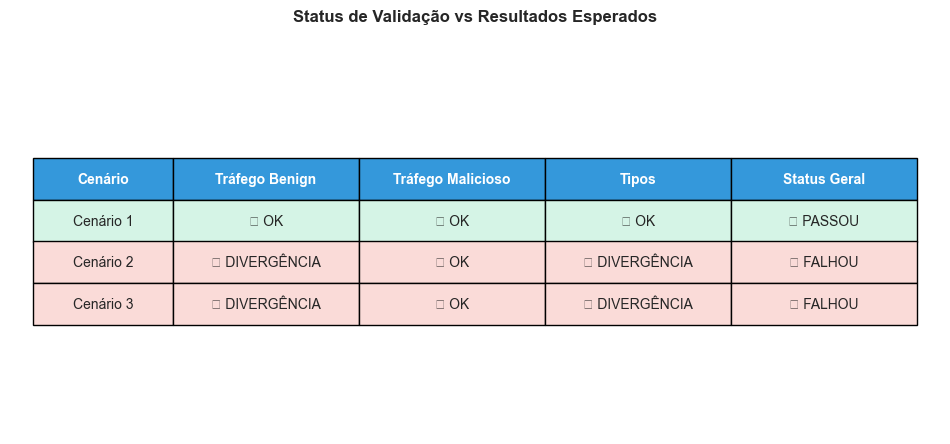


✅ Status de validação salvo em gráfico


In [26]:
# Visualizar status de validação
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('tight')
ax.axis('off')

validation_data = []
for scenario_name, validation in validation_results.items():
    benign_status = "✅ OK" if validation['benign_ok'] else "❌ DIVERGÊNCIA"
    attack_status = "✅ OK" if validation['attack_ok'] else "❌ DIVERGÊNCIA"
    types_status = "✅ OK" if validation['types_ok'] else "❌ DIVERGÊNCIA"
    overall = "✅ PASSOU" if all(validation.values()) else "❌ FALHOU"
    
    validation_data.append([scenario_name, benign_status, attack_status, types_status, overall])

table = ax.table(
    cellText=validation_data, 
    colLabels=['Cenário', 'Tráfego Benign', 'Tráfego Malicioso', 'Tipos', 'Status Geral'],
    cellLoc='center', 
    loc='center',
    colWidths=[0.15, 0.20, 0.20, 0.20, 0.20]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Colorir header
for i in range(5):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Colorir linhas baseado no status
for i in range(1, len(validation_data) + 1):
    overall_status = validation_data[i-1][4]
    if "PASSOU" in overall_status:
        color = '#d5f4e6'
    else:
        color = '#fadbd8'
    
    for j in range(5):
        table[(i, j)].set_facecolor(color)

plt.title('Status de Validação vs Resultados Esperados', 
         fontsize=12, fontweight='bold', pad=20)
plt.savefig(results_path / 'validacao_esperados.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Status de validação salvo em gráfico")


## 7. Estatísticas de Arquivos e Dados Brutos

ESTATÍSTICAS DE ARQUIVOS

Cenário 1:
----------------------------------------
  cve5g_s1_filtered.pcap: 47.68 MB
  cve5g_s1_labels.csv: 0.13 KB

Cenário 2:
----------------------------------------
  amf_crash_s2.log: 4.45 KB
  amf_crash_s2.log.before: 1.67 KB
  cve5g_s2_filtered.pcap: 31.62 MB
  cve5g_s2_labels.csv: 0.45 KB

Cenário 3:
----------------------------------------
  amf_crash_s3.log: 4.58 KB
  amf_crash_s3.log.before: 1.98 KB
  cve5g_s3_filtered.pcap: 22.20 MB
  cve5g_s3_labels.csv: 0.45 KB


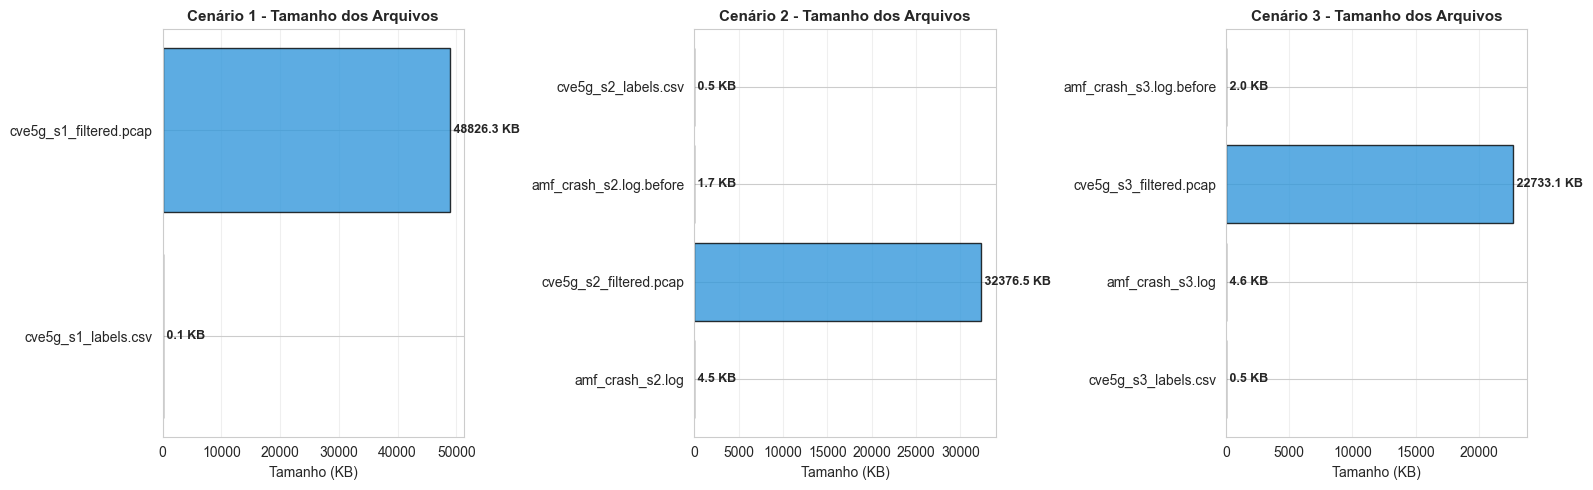


✅ Gráfico de tamanho de arquivos salvo


In [27]:
# Estatísticas de arquivos
import os

print("="*80)
print("ESTATÍSTICAS DE ARQUIVOS")
print("="*80)

file_stats = {}
for i in range(1, 4):
    scenario_path = results_path / f'scenario {i}'
    print(f"\nCenário {i}:")
    print("-" * 40)
    
    files = list(scenario_path.glob('*'))
    for file_path in sorted(files):
        if file_path.is_file():
            size_mb = file_path.stat().st_size / (1024 * 1024)
            size_kb = file_path.stat().st_size / 1024
            
            if size_mb > 1:
                size_str = f"{size_mb:.2f} MB"
            else:
                size_str = f"{size_kb:.2f} KB"
            
            print(f"  {file_path.name}: {size_str}")

# Gráfico de distribuição de tamanhos de arquivo
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, i in enumerate(range(1, 4)):
    scenario_path = results_path / f'scenario {i}'
    files_info = []
    
    for file_path in scenario_path.glob('*'):
        if file_path.is_file():
            size_kb = file_path.stat().st_size / 1024
            files_info.append({
                'name': file_path.name,
                'size_kb': size_kb
            })
    
    if files_info:
        names = [f['name'] for f in files_info]
        sizes = [f['size_kb'] for f in files_info]
        
        colors = ['#3498db' if 'pcap' in n else '#e74c3c' for n in names]
        axes[idx].barh(names, sizes, color=colors, edgecolor='black', alpha=0.8)
        axes[idx].set_xlabel('Tamanho (KB)', fontsize=10)
        axes[idx].set_title(f'Cenário {i} - Tamanho dos Arquivos', fontsize=11, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)
        
        # Adicionar valores nas barras
        for j, size in enumerate(sizes):
            axes[idx].text(size, j, f' {size:.1f} KB', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(results_path / 'tamanho_arquivos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico de tamanho de arquivos salvo")


## 8. Dados Brutos por Cenário

In [28]:
for scenario_name, result in analysis_results.items():
    print(f"\n{'='*80}")
    print(f"{scenario_name} - Dados Brutos")
    print(f"{'='*80}")
    print(result['df'].to_string(index=True))
    print(f"\nEstatísticas:")
    print(result['df'].describe(include='all').to_string())



Cenário 1 - Dados Brutos
                label    src_ip               dst_ip  t_start  t_end traffic_type traffic_category  duration
0      benign_iso_tcp  10.0.0.2  releases.ubuntu.com       30    300       Benign          iso_tcp       270
1  benign_ytdlp_https  10.0.0.2          youtube.com       30    300       Benign      ytdlp_https       270

Estatísticas:
                 label    src_ip               dst_ip  t_start  t_end traffic_type traffic_category  duration
count                2         2                    2      2.0    2.0            2                2       2.0
unique               2         1                    2      NaN    NaN            1                2       NaN
top     benign_iso_tcp  10.0.0.2  releases.ubuntu.com      NaN    NaN       Benign          iso_tcp       NaN
freq                 1         2                    1      NaN    NaN            2                1       NaN
mean               NaN       NaN                  NaN     30.0  300.0          NaN